In [5]:
import sys
sys.path.append("..")
import os
import pandas as pd
import pickle
from tqdm import tqdm
import numpy as np

In [6]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Linguistic Confidence",
    "dist_semantic_uncertainty": "Dist. Semantic Uncertainty",
    "dist_lnll": "Dist. Token Probability"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "trivia_qa": "TriviaQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [7]:
def _leaf_dirs(root_dir):
    leaf_dirs = []
    for root, dirs, files in os.walk(root_dir):
        if not dirs:
            leaf_dirs.append(root)
    return sorted(leaf_dirs)

def extract_sigma(string: str) -> float:
    # Extract the number after "sigma=" and before the next comma or end of string
    import re
    match = re.search(r"sigma=([\d\.]+)", string)
    if match:
        return float(match.group(1))
    else:
        raise ValueError(f"Could not extract sigma from string: {string}")


models = []
datasets = []

sigma_map = {
    "Linguistic Confidence": [],
    "Token Probability": [],
    "Semantic Uncertainty": []
}

dataset_instance_counts = {dataset: 0 for dataset in dataset_map.keys()}

for dataset in dataset_map.keys():
    lc = f"/hdd/ivny/results/{dataset}/hedged_qa_unified_lc"
    tp = f"/hdd/ivny/results/{dataset}/hedged_qa_unified_tp"
    su = f"/hdd/ivny/results/{dataset}/hedged_qa_unified_su"

    lc_leaf_dirs = _leaf_dirs(lc)
    tp_leaf_dirs = _leaf_dirs(tp)
    su_leaf_dirs = _leaf_dirs(su)

    for lc_, tp_, su_ in zip(lc_leaf_dirs, tp_leaf_dirs, su_leaf_dirs):
        lc_conf_path = os.path.join(lc_, "eval_details.csv")
        tp_conf_path = os.path.join(tp_, "eval_details.csv")
        su_conf_path = os.path.join(su_, "eval_details.csv")

        lc_sigmas = pd.read_csv(lc_conf_path)["confidence_0"].apply(extract_sigma).tolist()
        tp_sigmas = pd.read_csv(tp_conf_path)["confidence_0"].apply(extract_sigma).tolist()
        su_sigmas = pd.read_csv(su_conf_path)["confidence_0"].apply(extract_sigma).tolist()

        sigma_map["Linguistic Confidence"].extend(lc_sigmas)
        sigma_map["Token Probability"].extend(tp_sigmas)
        sigma_map["Semantic Uncertainty"].extend(su_sigmas)
        

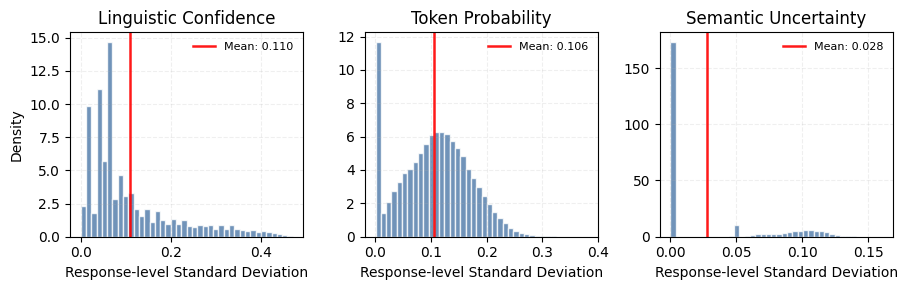

In [9]:
import matplotlib.pyplot as plt
import numpy as np

keys = list(sigma_map.keys())
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)

for ax, key in zip(axes, keys):
    values = sigma_map.get(key, [])
    ax.hist(values, bins=40, color="#4C78A8", alpha=0.8, edgecolor="white", density=True)

    mean_val = float(np.mean(values)) if len(values) > 0 else np.nan
    if np.isfinite(mean_val):
        ax.axvline(
            mean_val,
            color="red",
            linestyle="-",
            linewidth=1.8,
            alpha=0.9,
            label=f"Mean: {mean_val:.3f}",
        )
        ax.legend(loc="upper right", frameon=False, fontsize=8)

    ax.set_title(key)
    ax.set_xlabel("Response-level Standard Deviation")
    ax.grid(alpha=0.2, linestyle="--")

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("response_level_confidence_std_distributions.pdf", dpi=300, bbox_inches="tight")